In [1]:
# ── CELL 1: IMPORTS AND DATA LOAD ────────────────────────────────────────────
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

contracts = pd.read_excel('contracts.xlsx')
trades = pd.read_csv('daily_trades.csv')

trades['trade_date'] = pd.to_datetime(trades['trade_date'])
contracts['t0_date'] = pd.to_datetime(contracts['t0_date'])
contracts['first_trade_date'] = pd.to_datetime(contracts['first_trade_date'])

print('Contracts:', len(contracts))
print('Trade rows:', len(trades))
print('\nContracts columns:', contracts.columns.tolist())
print('Trades columns:', trades.columns.tolist())

Contracts: 41
Trade rows: 5189

Contracts columns: ['contract_name', 'group', 'condition_id', 't0_date', 'first_trade_date', 'resolved_outcome', 'direction', 'information_type']
Trades columns: ['trade_date', 'condition_id', 'question', 'total_volume', 'avg_price', 'num_trades']


In [2]:
# ── CELL 2: MERGE AND DAYS TO EVENT ─────────────────────────────────────────
df = trades.merge(
    contracts[['condition_id', 'contract_name', 'group', 't0_date',
               'first_trade_date', 'resolved_outcome', 'information_type', 'direction']],
    on='condition_id',
    how='left'
)

df['days_to_event'] = (df['trade_date'] - df['t0_date']).dt.days

print('Total rows after merge:', len(df))
print('Rows with missing group:', df['group'].isna().sum())
print('Rows with missing t0_date:', df['t0_date'].isna().sum())
print('\nContracts represented:', df['condition_id'].nunique())
print('\nDays to event range:', df['days_to_event'].min(), 'to', df['days_to_event'].max())

Total rows after merge: 5189
Rows with missing group: 0
Rows with missing t0_date: 0

Contracts represented: 41

Days to event range: -365 to 29


In [3]:
# ── CELL 3: ZERO-FILL MISSING DAYS ──────────────────────────────────────────
all_contracts = df['condition_id'].unique()
filled_rows = []

for cid in all_contracts:
    contract_df = df[df['condition_id'] == cid].copy()
    meta = contracts[contracts['condition_id'] == cid].iloc[0]

    date_range = pd.date_range(
        start=contract_df['trade_date'].min(),
        end=meta['t0_date'] + pd.Timedelta(days=30),
        freq='D'
    )

    contract_df = contract_df.set_index('trade_date').reindex(date_range).reset_index()
    contract_df.rename(columns={'index': 'trade_date'}, inplace=True)

    contract_df['condition_id'] = cid
    contract_df['contract_name'] = meta['contract_name']
    contract_df['group'] = meta['group']
    contract_df['t0_date'] = meta['t0_date']
    contract_df['information_type'] = meta['information_type']
    contract_df['direction'] = meta['direction']
    contract_df['total_volume'] = contract_df['total_volume'].fillna(0)
    contract_df['avg_price'] = contract_df['avg_price'].ffill()
    contract_df['num_trades'] = contract_df['num_trades'].fillna(0)
    contract_df['days_to_event'] = (contract_df['trade_date'] - meta['t0_date']).dt.days

    filled_rows.append(contract_df)

df_filled = pd.concat(filled_rows, ignore_index=True)

print('Rows after filling zeros:', len(df_filled))
print('Zero volume days added:', len(df_filled) - len(df))
print('Direction column present:', 'direction' in df_filled.columns)
print('Direction values:', df_filled['direction'].value_counts().to_dict())

Rows after filling zeros: 6691
Zero volume days added: 1502
Direction column present: True
Direction values: {1: 5060, -1: 1631}


In [4]:
# ── CELL 4: EVENT STUDY — CAV AND CAPD ──────────────────────────────────────
ESTIMATION_START = -60
ESTIMATION_END = -8
EVENT_START = -7
EVENT_END = -1

EXCLUDE = ['Will Rory McIlroy win The 2026 Masters tournament?']

results = []

for cid in df_filled['condition_id'].unique():
    contract = df_filled[df_filled['condition_id'] == cid].copy()
    meta = contracts[contracts['condition_id'] == cid].iloc[0]

    if meta['contract_name'] in EXCLUDE:
        print(f"Excluding {meta['contract_name'][:50]}")
        continue

    estimation = contract[
        (contract['days_to_event'] >= ESTIMATION_START) &
        (contract['days_to_event'] <= ESTIMATION_END)
    ]
    event = contract[
        (contract['days_to_event'] >= EVENT_START) &
        (contract['days_to_event'] <= EVENT_END)
    ]

    if len(estimation) < 8 or len(event) < 7:
        print(f"Skipping {meta['contract_name'][:50]} - insufficient data")
        continue

    vol_mean = estimation['total_volume'].mean()
    vol_std = estimation['total_volume'].std()
    price_mean = estimation['avg_price'].mean()
    price_std = estimation['avg_price'].std()

    if vol_std == 0 or price_std == 0:
        print(f"Skipping {meta['contract_name'][:50]} - zero std dev")
        continue

    direction = meta['direction']
    av_list = []
    apd_list = []

    for day in range(EVENT_START, EVENT_END + 1):
        day_data = event[event['days_to_event'] == day]
        if len(day_data) == 0:
            av_list.append(0)
            apd_list.append(0)
        else:
            vol = day_data['total_volume'].values[0]
            price = day_data['avg_price'].values[0]
            av = (vol - vol_mean) / vol_std
            apd = direction * (price - price_mean) / price_std
            av_list.append(av)
            apd_list.append(apd)

    cav = sum(av_list)
    capd = sum(apd_list)

    if len(estimation) >= 52:
        window_flag = 'Full'
    elif len(estimation) >= 30:
        window_flag = 'Shortened'
    else:
        window_flag = 'Short'

    results.append({
        'condition_id': cid,
        'contract_name': meta['contract_name'],
        'group': meta['group'],
        'information_type': meta['information_type'],
        'resolved_outcome': meta['resolved_outcome'],
        'direction': direction,
        'cav': cav,
        'capd': capd,
        'estimation_days': len(estimation),
        'window_flag': window_flag,
        'av_series': av_list,
        'apd_series': apd_list
    })

results_df = pd.DataFrame(results)
print(f"Contracts analysed: {len(results_df)}")
print(f"\nCAV by group:")
print(results_df.groupby('group')['cav'].mean().round(3))
print(f"\nCAPD by group:")
print(results_df.groupby('group')['capd'].mean().round(3))
print(f"\nWindow flags:")
print(results_df['window_flag'].value_counts())

Excluding Will Rory McIlroy win The 2026 Masters tournament?
Contracts analysed: 40

CAV by group:
group
1.1    25.883
1.2    49.851
2.0    21.848
3.0    12.746
4.0    16.749
Name: cav, dtype: float64

CAPD by group:
group
1.1   -1.411
1.2    0.053
2.0   -7.495
3.0   -0.251
4.0    2.566
Name: capd, dtype: float64

Window flags:
Full         24
Shortened    11
Short         5
Name: window_flag, dtype: int64


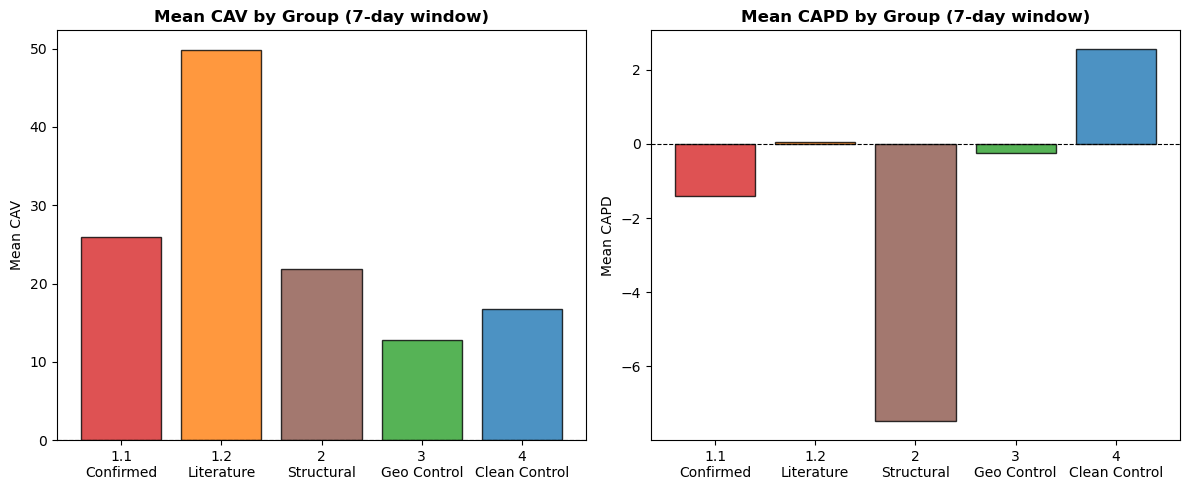

Saved group_means.png


In [5]:
# ── CELL 5: GROUP MEANS BAR CHART (Figure 5.1) ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

groups = ['1.1\nConfirmed', '1.2\nLiterature', '2\nStructural',
          '3\nGeo Control', '4\nClean Control']

cav_means = [
    results_df[results_df['group']==1.1]['cav'].mean(),
    results_df[results_df['group']==1.2]['cav'].mean(),
    results_df[results_df['group']==2.0]['cav'].mean(),
    results_df[results_df['group']==3.0]['cav'].mean(),
    results_df[results_df['group']==4.0]['cav'].mean()
]
capd_means = [
    results_df[results_df['group']==1.1]['capd'].mean(),
    results_df[results_df['group']==1.2]['capd'].mean(),
    results_df[results_df['group']==2.0]['capd'].mean(),
    results_df[results_df['group']==3.0]['capd'].mean(),
    results_df[results_df['group']==4.0]['capd'].mean()
]
colors = ['#d62728', '#ff7f0e', '#8c564b', '#2ca02c', '#1f77b4']

axes[0].bar(groups, cav_means, color=colors, alpha=0.8, edgecolor='black')
axes[0].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Mean CAV by Group (7-day window)', fontweight='bold')
axes[0].set_ylabel('Mean CAV')

axes[1].bar(groups, capd_means, color=colors, alpha=0.8, edgecolor='black')
axes[1].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Mean CAPD by Group (7-day window)', fontweight='bold')
axes[1].set_ylabel('Mean CAPD')

plt.tight_layout()
plt.savefig('group_means.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved group_means.png')

In [6]:
# ── CELL 6: ESTIMATION WINDOW SUMMARY ───────────────────────────────────────
print(results_df.groupby('group')['estimation_days'].agg(['mean', 'median', 'min', 'max', 'count']).round(1))

       mean  median  min  max  count
group                               
1.1    24.1    15.0    9   53      7
1.2    51.0    53.0   47   53      3
2.0    43.4    45.0   33   53      5
3.0    46.5    53.0   29   53     11
4.0    52.6    53.0   47   53     14


In [7]:
# ── CELL 7: CLUSTERING GROUP 1.1 ────────────────────────────────────────────
# Van Dyke: average four contracts into one cluster
vd_mask = results_df['contract_name'].str.contains('Venezuela|Maduro|War Powers|forces in Venezuela', case=False)
vd_avg_cav  = results_df[(results_df['group'] == 1.1) & vd_mask]['cav'].mean()
vd_avg_capd = results_df[(results_df['group'] == 1.1) & vd_mask]['capd'].mean()

# Ziv: single contract
ziv_mask = results_df['contract_name'].str.contains('Iran.*July', case=False)
ziv_cav  = results_df[(results_df['group'] == 1.1) & ziv_mask]['cav'].values[0]
ziv_capd = results_df[(results_df['group'] == 1.1) & ziv_mask]['capd'].values[0]

# Spagnuolo: two separate contracts, kept as independent observations
spag_mask = results_df['contract_name'].str.contains('Google|Searched', case=False)
spag_cav  = results_df[(results_df['group'] == 1.1) & spag_mask]['cav'].values
spag_capd = results_df[(results_df['group'] == 1.1) & spag_mask]['capd'].values

# Build clustered arrays
g1_1_cav  = np.array([vd_avg_cav,  ziv_cav,  *spag_cav])
g1_1_capd = np.array([vd_avg_capd, ziv_capd, *spag_capd])

print(f"Van Dyke cluster  CAV: {vd_avg_cav:.3f},  CAPD: {vd_avg_capd:.3f}")
print(f"Ziv               CAV: {ziv_cav:.3f},  CAPD: {ziv_capd:.3f}")
print(f"Spagnuolo 1       CAV: {spag_cav[0]:.3f}, CAPD: {spag_capd[0]:.3f}")
print(f"Spagnuolo 2       CAV: {spag_cav[1]:.3f},  CAPD: {spag_capd[1]:.3f}")
print(f"\nGroup 1.1 n (clustered): {len(g1_1_cav)}")

Van Dyke cluster  CAV: 23.498,  CAPD: -4.203
Ziv               CAV: 80.531,  CAPD: 7.383
Spagnuolo 1       CAV: -0.439, CAPD: -4.241
Spagnuolo 2       CAV: 7.097,  CAPD: 3.790

Group 1.1 n (clustered): 4


In [8]:
# ── CELL 8: BUILD ALL GROUP ARRAYS ──────────────────────────────────────────
g1_2_cav  = results_df[results_df['group'] == 1.2]['cav'].values
g2_cav    = results_df[results_df['group'] == 2.0]['cav'].values
g3_cav    = results_df[results_df['group'] == 3.0]['cav'].values
g4_cav    = results_df[results_df['group'] == 4.0]['cav'].values

g1_2_capd = results_df[results_df['group'] == 1.2]['capd'].values
g2_capd   = results_df[results_df['group'] == 2.0]['capd'].values
g3_capd   = results_df[results_df['group'] == 3.0]['capd'].values
g4_capd   = results_df[results_df['group'] == 4.0]['capd'].values

# Combined arrays for the three tests
validation_cav  = np.concatenate([g1_1_cav,  g1_2_cav])           # Test 1: 1.1+1.2
treatment_cav   = np.concatenate([g1_1_cav,  g1_2_cav,  g2_cav])  # Test 2: 1.1+1.2+2
control_cav     = np.concatenate([g3_cav,    g4_cav])              # Test 3: 3+4

validation_capd = np.concatenate([g1_1_capd, g1_2_capd])
treatment_capd  = np.concatenate([g1_1_capd, g1_2_capd, g2_capd])
control_capd    = np.concatenate([g3_capd,   g4_capd])

print(f"Validation n (1.1+1.2):    {len(validation_cav)}")
print(f"Treatment n  (1.1+1.2+2):  {len(treatment_cav)}")
print(f"Control n    (3+4):        {len(control_cav)}")

Validation n (1.1+1.2):    7
Treatment n  (1.1+1.2+2):  12
Control n    (3+4):        25


In [9]:
# ── CELL 9: STATISTICAL TESTS ────────────────────────────────────────────────
print("=== CAV ===")
t, p = stats.ttest_1samp(validation_cav, 0, alternative='greater')
print(f"Test 1  Validation (1.1+1.2) vs zero:  mean={validation_cav.mean():.3f}, n={len(validation_cav)}, t={t:.3f}, p={p:.4f}")
t1_cav, p1_cav = t, p

t, p = stats.ttest_1samp(treatment_cav, 0, alternative='greater')
print(f"Test 2  Treatment (1.1+1.2+2) vs zero: mean={treatment_cav.mean():.3f}, n={len(treatment_cav)}, t={t:.3f}, p={p:.4f}")
t2_cav, p2_cav = t, p

t, p = stats.ttest_1samp(control_cav, 0, alternative='greater')
print(f"Test 3  Control (3+4) vs zero:         mean={control_cav.mean():.3f}, n={len(control_cav)}, t={t:.3f}, p={p:.4f}")
t3_cav, p3_cav = t, p

print("\n=== CAPD ===")
t, p = stats.ttest_1samp(validation_capd, 0, alternative='greater')
print(f"Test 1  Validation (1.1+1.2) vs zero:  mean={validation_capd.mean():.3f}, n={len(validation_capd)}, t={t:.3f}, p={p:.4f}")
t1_capd, p1_capd = t, p

t, p = stats.ttest_1samp(treatment_capd, 0, alternative='greater')
print(f"Test 2  Treatment (1.1+1.2+2) vs zero: mean={treatment_capd.mean():.3f}, n={len(treatment_capd)}, t={t:.3f}, p={p:.4f}")
t2_capd, p2_capd = t, p

t, p = stats.ttest_1samp(control_capd, 0, alternative='greater')
print(f"Test 3  Control (3+4) vs zero:         mean={control_capd.mean():.3f}, n={len(control_capd)}, t={t:.3f}, p={p:.4f}")
t3_capd, p3_capd = t, p

print("\n=== NON-PARAMETRIC ===")
print("Wilcoxon Validation CAV:  ", stats.wilcoxon(validation_cav))
print("Wilcoxon Treatment CAV:   ", stats.wilcoxon(treatment_cav))
print("Wilcoxon Control CAV:     ", stats.wilcoxon(control_cav))
print("Wilcoxon Validation CAPD: ", stats.wilcoxon(validation_capd))
print("Wilcoxon Treatment CAPD:  ", stats.wilcoxon(treatment_capd))
print("Wilcoxon Control CAPD:    ", stats.wilcoxon(control_capd))

=== CAV ===
Test 1  Validation (1.1+1.2) vs zero:  mean=37.177, n=7, t=2.413, p=0.0262
Test 2  Treatment (1.1+1.2+2) vs zero: mean=30.790, n=12, t=2.947, p=0.0066
Test 3  Control (3+4) vs zero:         mean=14.988, n=25, t=4.881, p=0.0000

=== CAPD ===
Test 1  Validation (1.1+1.2) vs zero:  mean=0.412, n=7, t=0.242, p=0.4085
Test 2  Treatment (1.1+1.2+2) vs zero: mean=-2.882, n=12, t=-1.601, p=0.9311
Test 3  Control (3+4) vs zero:         mean=1.326, n=25, t=1.075, p=0.1466

=== NON-PARAMETRIC ===
Wilcoxon Validation CAV:   WilcoxonResult(statistic=3.0, pvalue=0.078125)
Wilcoxon Treatment CAV:    WilcoxonResult(statistic=5.0, pvalue=0.0048828125)
Wilcoxon Control CAV:      WilcoxonResult(statistic=28.0, pvalue=8.803606033325195e-05)
Wilcoxon Validation CAPD:  WilcoxonResult(statistic=14.0, pvalue=1.0)
Wilcoxon Treatment CAPD:   WilcoxonResult(statistic=20.0, pvalue=0.1513671875)
Wilcoxon Control CAPD:     WilcoxonResult(statistic=116.0, pvalue=0.21998637914657593)


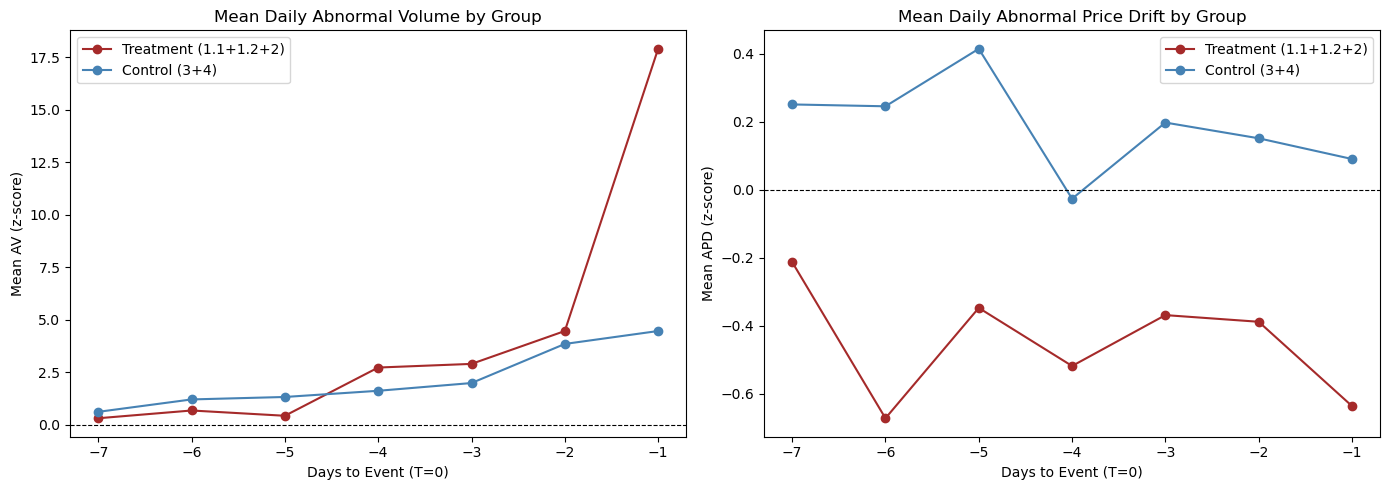

Saved event_window_treatment_vs_control.png


In [10]:
# ── CELL 10: EVENT WINDOW FIGURE — TREATMENT VS CONTROL ─────────────────────
treatment_groups = [1.1, 1.2, 2.0]
control_groups   = [3.0, 4.0]

# Compute daily AV and APD from df_filled using estimation window stats
event_window = df_filled[
    (df_filled['days_to_event'] >= -7) &
    (df_filled['days_to_event'] <= -1)
].copy()

estimation_window = df_filled[
    (df_filled['days_to_event'] >= -60) &
    (df_filled['days_to_event'] <= -8)
].copy()

# Exclude McIlroy
exclude_cids = contracts[contracts['contract_name'].isin(EXCLUDE)]['condition_id'].values
event_window = event_window[~event_window['condition_id'].isin(exclude_cids)]
estimation_window = estimation_window[~estimation_window['condition_id'].isin(exclude_cids)]

est_stats = estimation_window.groupby('condition_id').agg(
    mu_vol=('total_volume', 'mean'),
    sigma_vol=('total_volume', 'std'),
    mu_price=('avg_price', 'mean'),
    sigma_price=('avg_price', 'std')
).reset_index()

ew = event_window.merge(est_stats, on='condition_id', how='left')
ew['av']  = (ew['total_volume'] - ew['mu_vol']) / ew['sigma_vol']
ew['apd'] = ew['direction'] * (ew['avg_price'] - ew['mu_price']) / ew['sigma_price']
ew['group'] = ew['group'].round(1)

treat_ew = ew[ew['group'].isin(treatment_groups)]
ctrl_ew  = ew[ew['group'].isin(control_groups)]

treat_av  = treat_ew.groupby('days_to_event')['av'].mean()
ctrl_av   = ctrl_ew.groupby('days_to_event')['av'].mean()
treat_apd = treat_ew.groupby('days_to_event')['apd'].mean()
ctrl_apd  = ctrl_ew.groupby('days_to_event')['apd'].mean()

days = sorted(treat_av.index)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(days, [treat_av[d] for d in days],  marker='o', color='brown',     label='Treatment (1.1+1.2+2)')
axes[0].plot(days, [ctrl_av[d] for d in days],   marker='o', color='steelblue', label='Control (3+4)')
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_title('Mean Daily Abnormal Volume by Group')
axes[0].set_xlabel('Days to Event (T=0)')
axes[0].set_ylabel('Mean AV (z-score)')
axes[0].legend()

axes[1].plot(days, [treat_apd[d] for d in days], marker='o', color='brown',     label='Treatment (1.1+1.2+2)')
axes[1].plot(days, [ctrl_apd[d] for d in days],  marker='o', color='steelblue', label='Control (3+4)')
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Mean Daily Abnormal Price Drift by Group')
axes[1].set_xlabel('Days to Event (T=0)')
axes[1].set_ylabel('Mean APD (z-score)')
axes[1].legend()

plt.tight_layout()
plt.savefig('event_window_treatment_vs_control.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved event_window_treatment_vs_control.png')

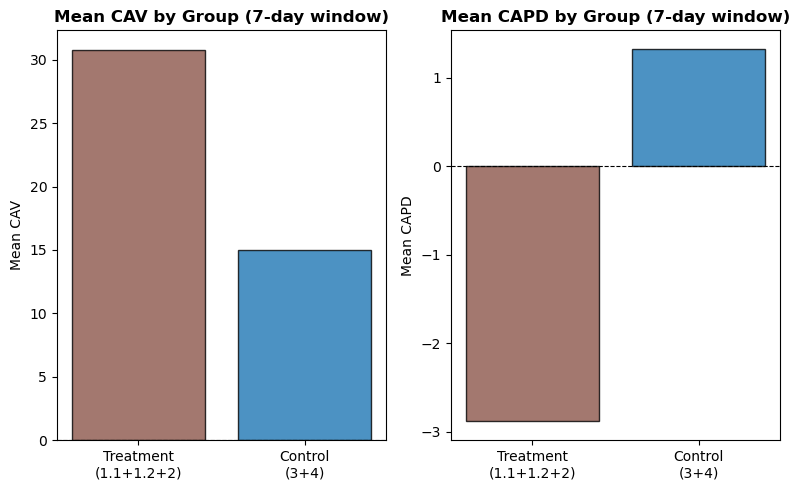

Saved group_means_consolidated.png


In [11]:
# ── CELL 11: CONSOLIDATED BAR CHART — TREATMENT VS CONTROL ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

grp_labels = ['Treatment\n(1.1+1.2+2)', 'Control\n(3+4)']
colors = ['#8c564b', '#1f77b4']

axes[0].bar(grp_labels, [treatment_cav.mean(), control_cav.mean()], color=colors, alpha=0.8, edgecolor='black')
axes[0].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Mean CAV by Group (7-day window)', fontweight='bold')
axes[0].set_ylabel('Mean CAV')

axes[1].bar(grp_labels, [treatment_capd.mean(), control_capd.mean()], color=colors, alpha=0.8, edgecolor='black')
axes[1].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Mean CAPD by Group (7-day window)', fontweight='bold')
axes[1].set_ylabel('Mean CAPD')

plt.tight_layout()
plt.savefig('group_means_consolidated.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved group_means_consolidated.png')

In [12]:
# ── CELL 12: SAVE KEY RESULTS ────────────────────────────────────────────────
with open('key_results.txt', 'w') as f:
    f.write("=== KEY RESULTS FOR WRITING ===\n")
    f.write("7-DAY EVENT WINDOW — DIRECTION-ADJUSTED CAPD\n\n")

    f.write("GROUP MEANS (unclustered, from results_df)\n")
    for grp, label in [(1.1,'1.1'), (1.2,'1.2'), (2.0,'2'), (3.0,'3'), (4.0,'4')]:
        cav_m  = results_df[results_df['group']==grp]['cav'].mean()
        capd_m = results_df[results_df['group']==grp]['capd'].mean()
        f.write(f"Group {label} CAV: {cav_m:.3f}, CAPD: {capd_m:.3f}\n")

    f.write("\nCLUSTERED VALUES — GROUP 1.1\n")
    f.write(f"Van Dyke  CAV: {vd_avg_cav:.3f}, CAPD: {vd_avg_capd:.3f}\n")
    f.write(f"Ziv       CAV: {ziv_cav:.3f}, CAPD: {ziv_capd:.3f}\n")
    f.write(f"Spagnuolo 1 CAV: {spag_cav[0]:.3f}, CAPD: {spag_capd[0]:.3f}\n")
    f.write(f"Spagnuolo 2 CAV: {spag_cav[1]:.3f}, CAPD: {spag_capd[1]:.3f}\n")

    f.write("\nTEST 1 — VALIDATION (1.1+1.2) VS ZERO\n")
    f.write(f"CAV:  mean={validation_cav.mean():.3f}, n={len(validation_cav)}, t={t1_cav:.3f}, p={p1_cav:.4f}\n")
    f.write(f"CAPD: mean={validation_capd.mean():.3f}, n={len(validation_capd)}, t={t1_capd:.3f}, p={p1_capd:.4f}\n")

    f.write("\nTEST 2 — TREATMENT (1.1+1.2+2) VS ZERO\n")
    f.write(f"CAV:  mean={treatment_cav.mean():.3f}, n={len(treatment_cav)}, t={t2_cav:.3f}, p={p2_cav:.4f}\n")
    f.write(f"CAPD: mean={treatment_capd.mean():.3f}, n={len(treatment_capd)}, t={t2_capd:.3f}, p={p2_capd:.4f}\n")

    f.write("\nTEST 3 — CONTROL (3+4) VS ZERO\n")
    f.write(f"CAV:  mean={control_cav.mean():.3f}, n={len(control_cav)}, t={t3_cav:.3f}, p={p3_cav:.4f}\n")
    f.write(f"CAPD: mean={control_capd.mean():.3f}, n={len(control_capd)}, t={t3_capd:.3f}, p={p3_capd:.4f}\n")

    f.write("\nNON-PARAMETRIC\n")
    w = stats.wilcoxon(validation_cav)
    f.write(f"Wilcoxon Validation CAV:  statistic={w.statistic}, p={w.pvalue:.4f}\n")
    w = stats.wilcoxon(treatment_cav)
    f.write(f"Wilcoxon Treatment CAV:   statistic={w.statistic}, p={w.pvalue:.4f}\n")
    w = stats.wilcoxon(control_cav)
    f.write(f"Wilcoxon Control CAV:     statistic={w.statistic}, p={w.pvalue:.4f}\n")
    w = stats.wilcoxon(validation_capd)
    f.write(f"Wilcoxon Validation CAPD: statistic={w.statistic}, p={w.pvalue:.4f}\n")
    w = stats.wilcoxon(treatment_capd)
    f.write(f"Wilcoxon Treatment CAPD:  statistic={w.statistic}, p={w.pvalue:.4f}\n")
    w = stats.wilcoxon(control_capd)
    f.write(f"Wilcoxon Control CAPD:    statistic={w.statistic}, p={w.pvalue:.4f}\n")

print('Saved key_results.txt')

Saved key_results.txt


Contracts excluded for price >= 0.9 on any event day: 3
  - Will Ukraine hold Kursk through 2024?
  - Trump, Putin, and Zelensky meet together by September 30?
  - Will 2025 be the hottest year on record?


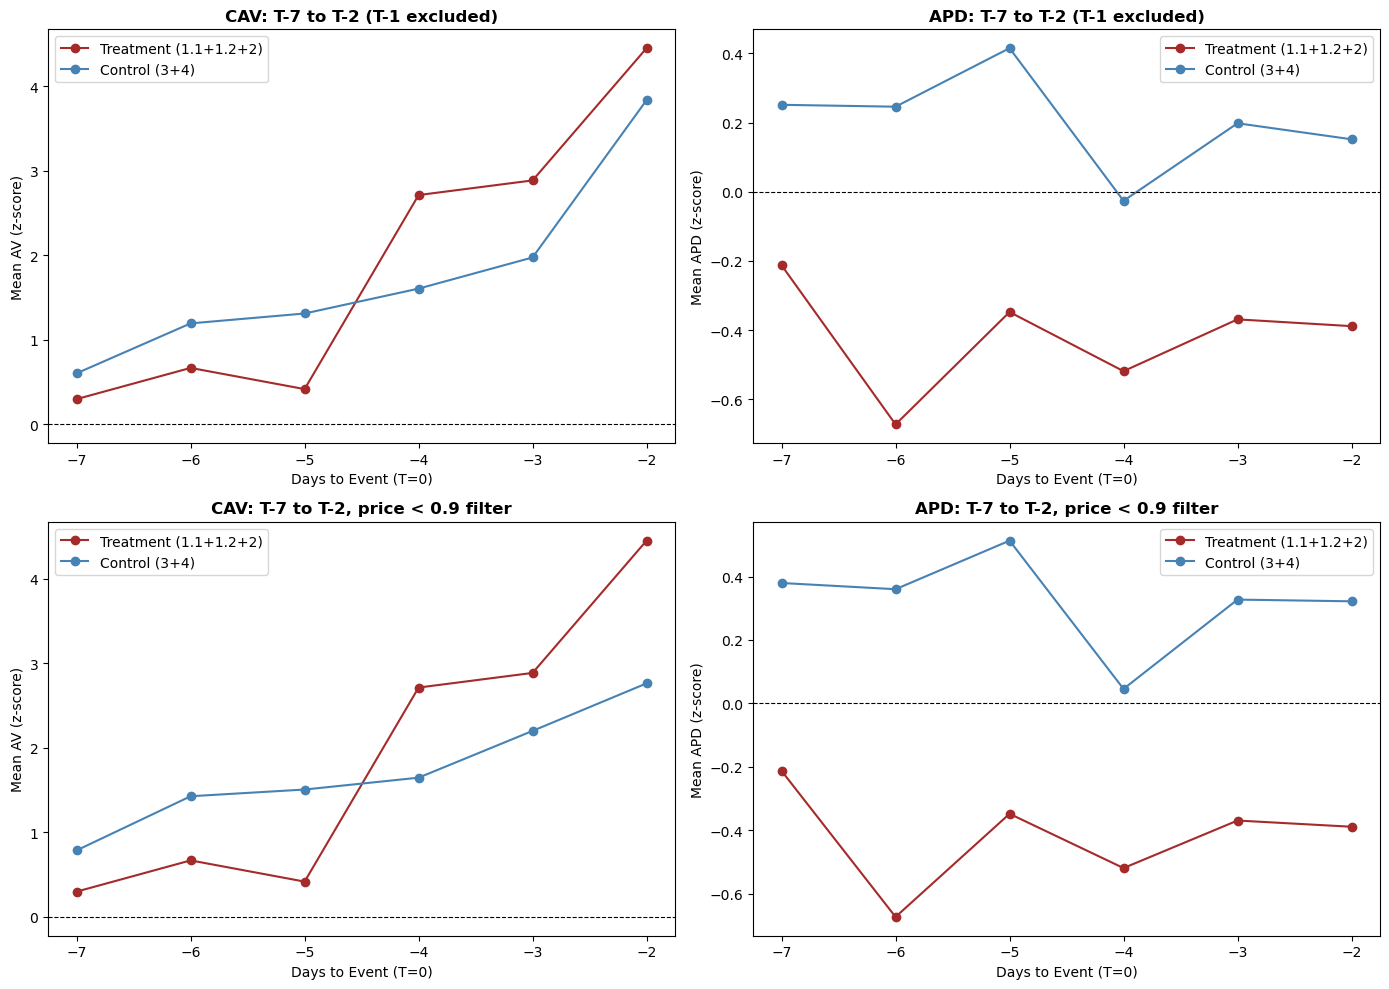

Saved event_window_robustness.png


In [ ]:
# ── CELL 13: EVENT WINDOW CHARTS — TWO ROBUSTNESS CUTS ──────────────────────

days_full = [-7, -6, -5, -4, -3, -2, -1]
days_trimmed = [-7, -6, -5, -4, -3, -2]  # Cut 1: drop T-1

# Identify contracts where avg_price >= 0.9 on any event day
high_price_cids = set(
    ew[ew['avg_price'] >= 0.9]['condition_id'].unique()
)
print(f"Contracts excluded for price >= 0.9 on any event day: {len(high_price_cids)}")
excluded_names = results_df[results_df['condition_id'].isin(high_price_cids)]['contract_name'].tolist()
for name in excluded_names:
    print(f"  - {name[:70]}")

ew_filtered = ew[~ew['condition_id'].isin(high_price_cids)]

# Helper to get mean AV and APD by group type and day list
def get_means(data, day_list):
    treat = data[data['group'].isin(treatment_groups)]
    ctrl  = data[data['group'].isin(control_groups)]
    t_av  = treat.groupby('days_to_event')['av'].mean()
    c_av  = ctrl.groupby('days_to_event')['av'].mean()
    t_apd = treat.groupby('days_to_event')['apd'].mean()
    c_apd = ctrl.groupby('days_to_event')['apd'].mean()
    return (
        [t_av.get(d, 0) for d in day_list],
        [c_av.get(d, 0) for d in day_list],
        [t_apd.get(d, 0) for d in day_list],
        [c_apd.get(d, 0) for d in day_list]
    )

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Cut 1: Drop T-1 ──────────────────────────────────────────────────────────
t_av, c_av, t_apd, c_apd = get_means(ew, days_trimmed)

axes[0, 0].plot(days_trimmed, t_av,  marker='o', color='brown',     label='Treatment (1.1+1.2+2)')
axes[0, 0].plot(days_trimmed, c_av,  marker='o', color='steelblue', label='Control (3+4)')
axes[0, 0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0, 0].set_title('AV: T-7 to T-2 (T-1 excluded)', fontweight='bold')
axes[0, 0].set_xlabel('Days to Event (T=0)')
axes[0, 0].set_ylabel('Mean AV (z-score)')
axes[0, 0].legend()

axes[0, 1].plot(days_trimmed, t_apd, marker='o', color='brown',     label='Treatment (1.1+1.2+2)')
axes[0, 1].plot(days_trimmed, c_apd, marker='o', color='steelblue', label='Control (3+4)')
axes[0, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0, 1].set_title('APD: T-7 to T-2 (T-1 excluded)', fontweight='bold')
axes[0, 1].set_xlabel('Days to Event (T=0)')
axes[0, 1].set_ylabel('Mean APD (z-score)')
axes[0, 1].legend()

# ── Cut 2: Drop T-1 and high-price contracts ─────────────────────────────────
t_av, c_av, t_apd, c_apd = get_means(ew_filtered, days_trimmed)

axes[1, 0].plot(days_trimmed, t_av,  marker='o', color='brown',     label='Treatment (1.1+1.2+2)')
axes[1, 0].plot(days_trimmed, c_av,  marker='o', color='steelblue', label='Control (3+4)')
axes[1, 0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1, 0].set_title('AV: T-7 to T-2, price < 0.9 filter', fontweight='bold')
axes[1, 0].set_xlabel('Days to Event (T=0)')
axes[1, 0].set_ylabel('Mean AV (z-score)')
axes[1, 0].legend()

axes[1, 1].plot(days_trimmed, t_apd, marker='o', color='brown',     label='Treatment (1.1+1.2+2)')
axes[1, 1].plot(days_trimmed, c_apd, marker='o', color='steelblue', label='Control (3+4)')
axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1, 1].set_title('APD: T-7 to T-2, price < 0.9 filter', fontweight='bold')
axes[1, 1].set_xlabel('Days to Event (T=0)')
axes[1, 1].set_ylabel('Mean APD (z-score)')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('event_window_robustness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved event_window_robustness.png')